<a href="https://colab.research.google.com/github/Dairo-Delgadillo-DEv/ML_House_Prices_Prediction/blob/main/ML_House_Prices_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# 1. Simulate loading a directory dataset (Image this is 'houses_spain.csv')
raw_data = {
    "Size_M2": [80, 120, np.nan, 150, 80, 200],
    "Price_EUR": [120000, 180000, 90000, np.nan, 120000, 350000],
    "City": ["Madrid", "Barcelona", "Madrid", "Valencia", "Madrid", "Barcelona"]
}

df = pd.DataFrame(raw_data)

print("--- 1. Original Dirty Data ---")
print(df)

# 2. Count missing values (NaN) in each column
print("\n--- 2. Missing Values Count ---")
print(df.isnull().sum())

# 3. Clean: Fill missing 'Size_M2' with the median size of the dataset
median_size = df["Size_M2"].median()
df["Size_M2"] = df["Size_M2"].fillna(median_size)

# 4. Clean: Remove rows where 'Price_EUR' is missing (we can't use them)
df = df.dropna(subset=["Price_EUR"])

# 5. Clean: Drop duplicate rows (Row 0 and are identical)
df = df.drop_duplicates()

print("\n--- 3. Cleaned Data Ready for ML ---")
print(df)

--- 1. Original Dirty Data ---
   Size_M2  Price_EUR       City
0     80.0   120000.0     Madrid
1    120.0   180000.0  Barcelona
2      NaN    90000.0     Madrid
3    150.0        NaN   Valencia
4     80.0   120000.0     Madrid
5    200.0   350000.0  Barcelona

--- 2. Missing Values Count ---
Size_M2      1
Price_EUR    1
City         0
dtype: int64

--- 3. Cleaned Data Ready for ML ---
   Size_M2  Price_EUR       City
0     80.0   120000.0     Madrid
1    120.0   180000.0  Barcelona
2    120.0    90000.0     Madrid
5    200.0   350000.0  Barcelona


In [ ]:
import numpy as np

# 1. Extracte the 'Price_EUR' column from our cleaned DataFrame into a Numpy array
prices_array = df["Price_EUR"].to_numpy()

print("--- 1. Prices as NamPy Array ---")
print(prices_array)
print(f"Data Type: {type(prices_array)}")

# 2. Vectosization: Convert all prices to thousands of Euros (divide by 1000)
# (NumPy does this to all elements at once without needing a 'for' Loop!)
prices_in_thousands = prices_array / 1000

print("\n--- 2. Prices in Thousands of EUR ---")
print(prices_in_thousands)

# 3. USe NmaPy mathematical funtions to analyze the prices
mean_price = np.mean(prices_in_thousands)
max_price = np.max(prices_in_thousands)
standard_deviation = np.std(prices_in_thousands)

print("\n--- 3. NumPy Statistical Summary ---")
print(f"MMean Price: {mean_price:.2f}k EUR")
print(f"Max Price: {max_price:.2f}k EUR")
print(f"Standard Deviation: {standard_deviation:.2f}k EUR")

--- 1. Prices as NamPy Array ---
[120000. 180000.  90000. 350000.]
Data Type: <class 'numpy.ndarray'>

--- 2. Prices in Thousands of EUR ---
[120. 180.  90. 350.]

--- 3. NumPy Statistical Summary ---
MMean Price: 185.00k EUR
Max Price: 350.00k EUR
Standard Deviation: 100.62k EUR


<function matplotlib.pyplot.show(close=None, block=None)>

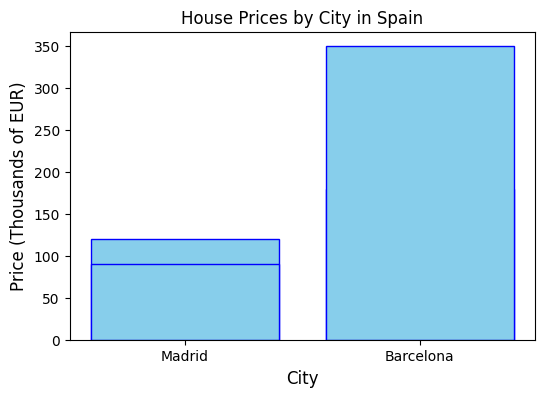

In [ ]:
import matplotlib.pyplot as plt

# 1. Define the data for the axes
cities = df["City"]
prices_k = df["Price_EUR"] / 1000  # Convert to thousands for a cleaner scale

# 2. Create a bar char
plt.figure(figsize=(6, 4))
plt.bar(cities, prices_k, color="skyblue", edgecolor="blue")

# 3. Add title and labels (Crucial for presentation!)
plt.title("House Prices by City in Spain", fontsize=12)
plt.xlabel("City", fontsize=12)
plt.ylabel("Price (Thousands of EUR)", fontsize=12)

# 4. Show the plot
plt.show

In [ ]:
from sklearn.linear_model import LinearRegression

# 1. Prepare features (X) and target (y)
# X must be a 2D array (DataFrame), Y can by 1D (Series)
x = df[["Size_M2"]]
y = df["Price_EUR"]

# 2. Instantiate the Linear Regression model
model = LinearRegression()

# 3. Train (fit) the model with our clean data
model.fit(x, y)

# 4. Predict the price for a new house of 100 m2
new_house = [[100]]
predicted_price = model.predict(new_house)

print("\n--- ML Prediction ---")
print(f"Predicted price for a 100 m2 house: {predicted_price[0]:,.2f} EUR")


--- ML Prediction ---
Predicted price for a 100 m2 house: 122,631.58 EUR


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Create a larger dataset of 10 houses
dataset = {
    "Size_M2": [50, 60, 70, 80, 90, 100, 110, 120, 130, 140],
    "Price_EUR": [90000, 110000, 130000, 150000, 170000, 190000, 210000, 230000, 250000, 270000]
}
df_large = pd.DataFrame(dataset)

x = df_large[["Size_M2"]]
y = df_large["Price_EUR"]

# 2. Split the data: 80% for training, 20% for testing
# 'Random_state' ensure we get the same split every time we run the code
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("--- Data Split Summary ---")
print(f"Total houses in dataset: {len(x)}")
print(f"Houses used for training (80%): {len(x_train)}")
print(f"Houses saved for testing (20%): {len(y_test)}")

print("\n--- Houses selected for testing ---")
print(x_test)

--- Data Split Summary ---
Total houses in dataset: 10
Houses used for training (80%): 8
Houses saved for testing (20%): 2

--- Houses selected for testing ---
   Size_M2
8      130
1       60


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# 1. Train the model ONLY with the training data
model = LinearRegression()
model.fit(x_train, y_train)

# 2. Make predictions on the test data (unseen by model)
predictions = model.predict(x_test)

# 3. Calculate the Mean Absolute Error (MAE)
# We compare the real price (y_test) against the predictions
mae = mean_absolute_error(y_test, predictions)

print("--- Model Evaluation ---")
for i, (real, pred) in enumerate(zip(y_test, predictions)):
  print(f"House {i+1}: Real Price = {real:,.2f} EUR | Predicted Price = {pred:,.2f} EUR")

print(f"\nMean Absolute Error (MAE): {mae:,.2f} EUR")

--- Model Evaluation ---
House 1: Real Price = 250,000.00 EUR | Predicted Price = 250,000.00 EUR
House 2: Real Price = 110,000.00 EUR | Predicted Price = 110,000.00 EUR

Mean Absolute Error (MAE): 0.00 EUR
